In [41]:
# ======================================================
# 0. 依赖
# ======================================================
import numpy as np
from numpy import pi, exp, sqrt, real, imag
from itertools import product
from scipy.linalg import expm
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator

In [42]:
# ======================================================
# 1. 经典侧：构造初态并做谱截断
# ======================================================
N   = 2**7                # 网格边长（32×32）
dt  = 10.0                 # 时间步
#dt = np.pi / 1
K_CUT = 3                 # ⚠️ 频域截断半宽 |k| ≤ K_CUT

# ---- 1.1 构造原始两分量波函数 (与你原脚本一致) ----
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)

sigma = 3.0
R     = np.sqrt(X**2 + Y**2)
f     = np.exp(-(R/sigma)**4)
u     = 2*(X+1j*Y)*f/(1+R**2)
v     = 1j*(R**2+1-2*f)/(1+R**2)

psi1_0 = u/np.sqrt(abs(u)**2+abs(v)**4)
psi2_0 = v**2/np.sqrt(abs(u)**2+abs(v)**4)

# ---- 1.2 FFT → 取低频模态 ----
kx_full = np.fft.fftfreq(N)*N          # 0,1,…,K,-K,…,-1
ky_full = np.fft.fftfreq(N)*N
psi1_k  = np.fft.fft2(psi1_0)
psi2_k  = np.fft.fft2(psi2_0)

# 保留 |kx|,|ky|≤K_CUT
mask    = [(ix,iy) for ix in range(-K_CUT, K_CUT+1)
                   for iy in range(-K_CUT, K_CUT+1)]
r       = 2*len(mask)                  # 两分量系数总数
q       = int(np.ceil(np.log2(r)))     # qubit 数

coeffs  = []
kx_list, ky_list = [], []
for ix, iy in mask:
    kx_idx = (ix+N) % N               # 映射回 0…N-1
    ky_idx = (iy+N) % N
    coeffs.append(psi1_k[ky_idx, kx_idx])  # 注意行列次序
for ix, iy in mask:
    kx_idx = (ix+N) % N
    ky_idx = (iy+N) % N
    coeffs.append(psi2_k[ky_idx, kx_idx])

# 归一化为量子态振幅
coeffs = np.array(coeffs, dtype=complex)
coeffs = coeffs/np.linalg.norm(coeffs)

print(f"📉 频域截断后模态 r = {r}, 量子比特 q = {q}")

📉 频域截断后模态 r = 98, 量子比特 q = 7


In [43]:
# ======================================================
# 2. 量子侧：准备压缩态并演化
# ======================================================
def kinetic_phase_diag(kx_vals, ky_vals, dt):
    """对角矩阵：e^{-i(kx²+ky²) dt/2}"""
    phase = [-0.5*dt*(kx**2 + ky**2) for kx,ky in zip(kx_vals, ky_vals)]
    return np.exp(1j*np.array(phase))

# ---- 2.1 生成 (kx,ky) 列表与对角相位 ----
kx_modes = [ix      for ix,iy in mask] + [ix for ix,iy in mask]  # psi1+psi2
ky_modes = [iy      for ix,iy in mask] + [iy for ix,iy in mask]
D_phase  = kinetic_phase_diag(kx_modes, ky_modes, dt)

# ---- 2.2 构造量子线路 ----
qc = QuantumCircuit(q)

state_dim = 1 << q          # = 2**q  (这里是 128)
full_state = np.zeros(state_dim, dtype=complex)
full_state[:r] = coeffs     # r = 98  个实幅度
# 其余 full_state[98:128] 保持 0

qc.initialize(full_state, qc.qubits)

# ===★  直接应用对角演化算符  ★===
# 在仿真器里可用 Operator；若部署在硬件上应拆为
# 多控 RZ / QSP / qDRIFT 等
# ===★  补全缺失相位（填 1） ★===
full_phase = np.ones(state_dim, dtype=complex)
full_phase[:r] = D_phase                       # 把 98 个实际相位放前面
U_full = np.diag(full_phase)                   # 128×128 对角矩阵

qc.append(Operator(U_full), qc.qubits)

qc.save_state()
sim   = AerSimulator(method='statevector')
qc    = transpile(qc, sim, optimization_level=2)
result = sim.run(qc).result()
psi_t  = result.data(0)['statevector']

In [44]:
# ======================================================
# 3. 经典侧：把压缩态重投影回实空间
# ======================================================
# ---- 3.1 拆回两分量谱系数 ----
psi1_k_t = np.zeros_like(psi1_k)
psi2_k_t = np.zeros_like(psi2_k)

for m,(ix,iy) in enumerate(mask):
    kx_idx = (ix+N)%N; ky_idx = (iy+N)%N
    psi1_k_t[ky_idx,kx_idx] = psi_t[m]
for m,(ix,iy) in enumerate(mask):
    kx_idx = (ix+N)%N; ky_idx = (iy+N)%N
    psi2_k_t[ky_idx,kx_idx] = psi_t[m+len(mask)]

# ---- 3.2 IFFT 得到 ψ1, ψ2 实空间 ----
psi1_t = np.fft.ifft2(psi1_k_t)
psi2_t = np.fft.ifft2(psi2_k_t)

In [45]:
# ======================================================
# 4. 后处理：涡量等物理量 (沿用你的 compute_fluid_quantities)
# ======================================================
def compute_fluid_quantities(psi1, psi2):
    kx = np.fft.fftfreq(N)*N
    ky = np.fft.fftfreq(N)*N
    KX, KY = np.meshgrid(kx, ky)
    psi1_spec = np.fft.fft2(psi1)
    dpsi1_x = np.fft.ifft2(1j*KX*psi1_spec)
    dpsi1_y = np.fft.ifft2(1j*KY*psi1_spec)
    psi2_spec = np.fft.fft2(psi2)
    dpsi2_x = np.fft.ifft2(1j*KX*psi2_spec)
    dpsi2_y = np.fft.ifft2(1j*KY*psi2_spec)
    rho = np.abs(psi1)**2 + np.abs(psi2)**2
    ux = real(real(psi1)*imag(dpsi1_x) - imag(psi1)*real(dpsi1_x)
              +real(psi2)*imag(dpsi2_x) - imag(psi2)*real(dpsi2_x)) / rho
    uy = real(real(psi1)*imag(dpsi1_y) - imag(psi1)*real(dpsi1_y)
              +real(psi2)*imag(dpsi2_y) - imag(psi2)*real(dpsi2_y)) / rho
    vor = real(np.fft.ifft2(1j*KX*np.fft.fft2(uy) - 1j*KY*np.fft.fft2(ux)))
    return rho, ux, uy, vor

rho, ux, uy, vor = compute_fluid_quantities(psi1_t, psi2_t)

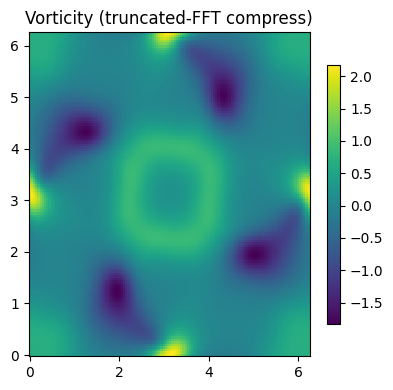

In [46]:
# ======================================================
# (可选) 画出涡量场 quick-look
# ======================================================
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))
x = np.linspace(0, 2*pi, N, endpoint=False)
X, Y = np.meshgrid(x, x)
im = ax.pcolormesh(X, Y, vor, cmap='viridis', shading='auto')
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Vorticity (truncated-FFT compress)")
plt.tight_layout()
plt.show()


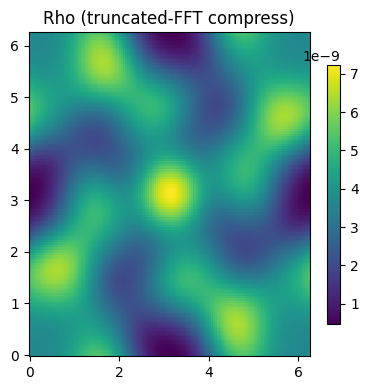

In [47]:
# ======================================================
# (可选) 画出密度场 quick-look
# ======================================================
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))
x = np.linspace(0, 2*pi, N, endpoint=False)
X, Y = np.meshgrid(x, x)
im = ax.pcolormesh(X, Y, rho, cmap='viridis', shading='auto')
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Rho (truncated-FFT compress)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_373133/347865934.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


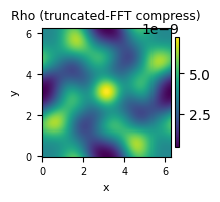

In [48]:
# ======================================================
# 画出密度场 quick-look —— 8 cm × 8 cm 版式
# ======================================================
import matplotlib.pyplot as plt
import numpy as np

fig_width  = 8 / 2.54          # 8 cm → inch
fig_height = 8 / 2.54
fig = plt.figure(figsize=(fig_width, fig_height))

# 4 cm × 4 cm 轴在左下角（与前例保持一致）
ax_width  = 4 / 2.54 / fig_width
ax_height = 4 / 2.54 / fig_height
ax = fig.add_axes([0, 0, ax_width, ax_height])
ax.set_box_aspect(1)           # 保证方形

# —— 主图 —— #
x = np.linspace(0, 2*np.pi, N, endpoint=False)
X, Y = np.meshgrid(x, x)
im = ax.pcolormesh(X, Y, rho, cmap='viridis', shading='auto')

# —— colorbar —— #
fig.colorbar(im, ax=ax, shrink=0.7, aspect=30, pad=0.03)

ax.set_title("Rho (truncated-FFT compress)", fontsize=9)
ax.set_xlabel("x", fontsize=8)
ax.set_ylabel("y", fontsize=8)
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()
